# 03_config_diagonal_uniform

- Diagonal covariance with compact continuous eigenvalue support [a, b].
- Config: `configs/config_diagonal_uniform.yaml`
- Workflow: simulate -> realized covariance spectrum -> MP inverse -> recovery metrics.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (
        p
        for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (p / 'pyproject.toml').exists() and (p / 'src' / 'mpdiff').exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate project root (expected pyproject.toml and src/mpdiff).')
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from mpdiff.config.loader import load_config
from mpdiff.experiments.run_end_to_end import run_end_to_end

config_path = PROJECT_ROOT / 'configs/config_diagonal_uniform.yaml'
cfg = load_config(config_path)
out_dir = Path(cfg.global_settings.output_dir)
out_dir


PosixPath('outputs/config_diagonal_uniform')

In [2]:
summary = run_end_to_end(config_path)
summary


2026-04-09 08:51:09,396 | INFO | mpdiff.experiments.run_full_pipeline | build_schedule completed in 0.027s
2026-04-09 08:51:09,456 | INFO | mpdiff.experiments.run_full_pipeline | Simulated diffusion: d=110, steps=480, horizon=1.000000
2026-04-09 08:51:09,476 | INFO | mpdiff.experiments.run_full_pipeline | simulation completed in 0.079s
2026-04-09 08:51:09,477 | INFO | mpdiff.experiments.run_full_pipeline | compute_increments completed in 0.000s
2026-04-09 08:51:09,484 | INFO | mpdiff.experiments.run_full_pipeline | realized_covariance completed in 0.005s
2026-04-09 08:51:09,486 | INFO | mpdiff.experiments.run_full_pipeline | eigendecomposition completed in 0.001s
2026-04-09 08:51:09,488 | INFO | mpdiff.experiments.run_full_pipeline | empirical_density_estimation completed in 0.002s
2026-04-09 08:51:57,635 | INFO | mpdiff.experiments.run_full_pipeline | mp_inverse completed in 48.147s
2026-04-09 08:51:57,770 | INFO | mpdiff.experiments.run_full_pipeline | reference_population completed 

{'method': 'fixed_point',
 'aspect_ratio': 0.23,
 'reference_population_mean': 1.0602257854007984,
 'estimated_population_mean': 1.107126178421562,
 'population_wasserstein_1': 0.12972831539075091,
 'reconstruction_l2': 0.05417443007290465,
 'output_dir': 'outputs/config_diagonal_uniform'}

In [3]:
summary_csv = out_dir / 'full_pipeline_method_summary.csv'
meta_json = out_dir / 'full_pipeline_metadata.json'
report_txt = out_dir / 'full_pipeline_report.txt'

df = pd.read_csv(summary_csv)
display(df)

meta = json.loads(meta_json.read_text())
print('timers (seconds):')
for k, v in meta['timers_seconds'].items():
    print(f'  {k}: {v:.4f}')

print('\nreport preview:')
print(report_txt.read_text()[:1600])


,method,estimated_population_mean,population_l1,population_l2,population_wasserstein_1,population_support_min_diff,population_support_max_diff,population_moment1_abs_error,population_moment2_abs_error,population_moment3_abs_error,reconstruction_l1,reconstruction_l2,reconstruction_wasserstein_1
0,moment_based,1.114476,0.306080,0.230222,0.069777,0.0,0.655106,0.054228,0.137118,0.354478,0.170322,0.167235,0.042916
1,optimization,1.147120,0.382886,0.297496,0.099376,0.0,1.579961,0.090137,0.224648,0.490829,0.043377,0.067676,0.032344
2,fixed_point,1.107126,0.632965,0.551242,0.129728,0.0,0.009634,0.053557,0.099463,0.097423,0.058840,0.054174,0.017631


timers (seconds):
  build_schedule: 0.0268
  compute_increments: 0.0001
  eigendecomposition: 0.0013
  empirical_density_estimation: 0.0016
  mp_inverse: 48.1467
  realized_covariance: 0.0055
  reference_population: 0.1346
  simulation: 0.0794

report preview:
mpdiff full pipeline report

config_path: /Users/gregoire.szymanski/Documents/random-matrices/configs/config_diagonal_uniform.yaml
aspect_ratio_c: 0.23
realized_covariance_normalization: total_time
primary_method: fixed_point

method summary (sorted by population_wasserstein_1):
      method  estimated_population_mean  population_l1  population_l2  population_wasserstein_1  population_support_min_diff  population_support_max_diff  population_moment1_abs_error  population_moment2_abs_error  population_moment3_abs_error  reconstruction_l1  reconstruction_l2  reconstruction_wasserstein_1
moment_based                   1.114476       0.306080       0.230222                  0.069777                          0.0                     0.

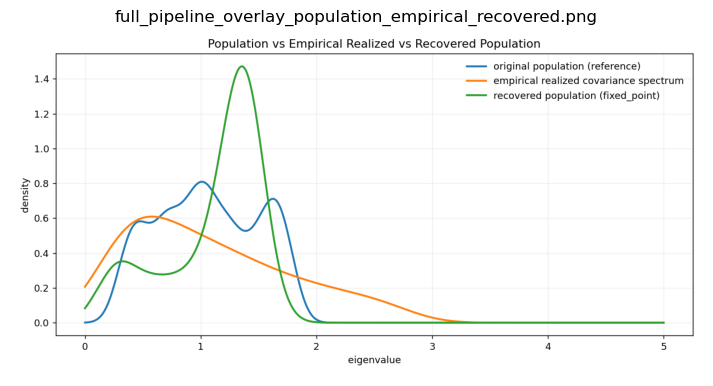

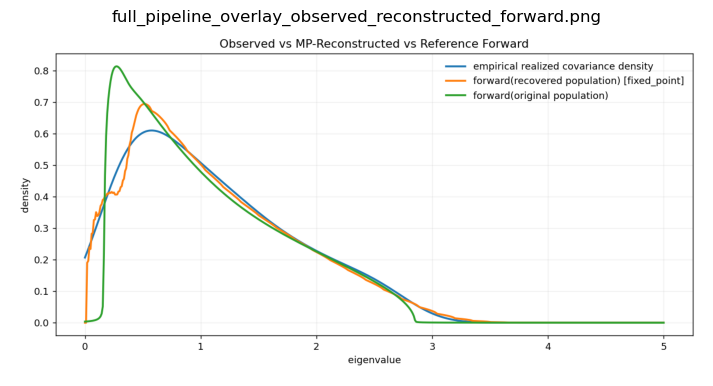

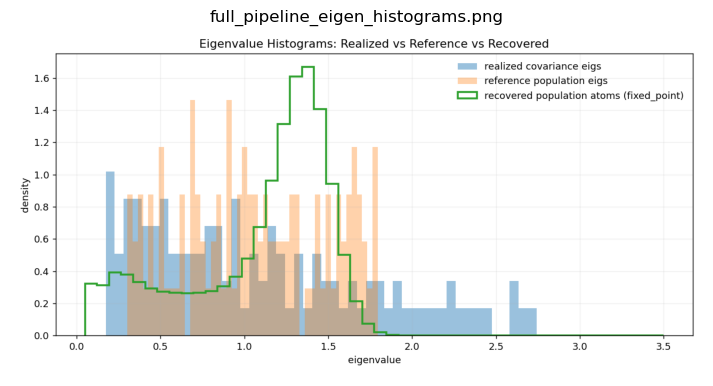

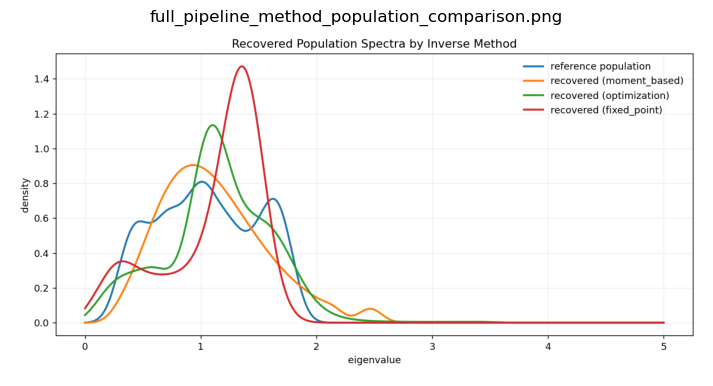

In [4]:
fig_paths = [
    out_dir / 'full_pipeline_overlay_population_empirical_recovered.png',
    out_dir / 'full_pipeline_overlay_observed_reconstructed_forward.png',
    out_dir / 'full_pipeline_eigen_histograms.png',
    out_dir / 'full_pipeline_method_population_comparison.png',
]

for p in fig_paths:
    if p.exists():
        img = mpimg.imread(p)
        plt.figure(figsize=(10, 4.5))
        plt.imshow(img)
        plt.title(p.name)
        plt.axis('off')
        plt.show()


## Interpretation Checklist

- Compare `population_wasserstein_1` and `reconstruction_l2` jointly.
- Inspect whether best method is stable across nearby config choices.
- For piecewise models, remember reference law is based on integrated covariance over time.
